## Init

In [1]:
import os
import numpy as np
import itertools as it
import random
import pandas as pd
import multiprocess as mp
import time
import sys
import matplotlib.pyplot as plt
import torch
import copy

from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.analysis_type import Classic
from pyrqa.neighbourhood import FixedRadius
from pyrqa.metric import EuclideanMetric
from pyrqa.computation import RQAComputation

pd.options.mode.copy_on_write = True

In [2]:
folder = "C:/Users/B00955739/Documents/Git/phd/Init/"

sys.path.append(folder)

import functions_v6_8 as fn
import ml_functions as mlf

In [3]:
folder = "C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/"
csv = "main_run_v2_corrected.csv"

In [4]:
out_name = "modelling_run_v1"

In [5]:
full_df = pd.read_csv(folder + csv)

## Sampling

In [6]:
full_df_np = full_df[full_df.system_periodic == False].copy()

In [7]:
full_df_np['largest_lyap_quartile'] = pd.qcut(x = full_df_np['largest_lyap'], q=4, labels=False)

In [8]:
full_df_np.head()

,Unnamed: 0.1,Unnamed: 0,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,...,lyap_4,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9,largest_lyap,corrected,lyap_spectrum_full,largest_lyap_quartile
0,0,0,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 1.41421356237309...",3.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,NaN,0.000016,False,"[1.5845574167039368e-05, nan, nan, nan, nan, n...",0
1,1,1,1,NN,0.1,[<functions_v6.sincircle_map object at 0x00000...,"[('sin_circle_map', {'omega': 0.5, 'k': 2})]",1.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,NaN,0.351925,False,"[0.3519253487725863, nan, nan, nan, nan, nan, ...",0
2,2,2,1,NN,0.1,[<functions_v6.tent_map object at 0x000002990D...,"[('tent_map', {'a': 1.9999999999, 'b': 27.2990...",3.0,False,[[1.]],...,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,False,"[3.999999999950663, nan, nan, nan, nan, nan, n...",3
3,3,3,1,NN,0.1,[<functions_v6.tent_map object at 0x00000298DC...,"[('tent_map', {'a': 1.9999999999, 'b': 1})]",0.5,True,[[1.]],...,NaN,NaN,NaN,NaN,NaN,NaN,0.693147,False,"[0.6931471805096966, nan, nan, nan, nan, nan, ...",1
4,4,4,1,NN,0.1,[<functions_v6.sluze_map object at 0x00000298E...,"[('sluze_map', {'m': 0.8, 'p': 0.2})]",0.5,True,[[1.]],...,NaN,NaN,NaN,NaN,NaN,NaN,0.417346,False,"[0.417345868882577, nan, nan, nan, nan, nan, n...",0


In [9]:
samp_size = 2

In [10]:
sample = full_df_np.groupby(['embed_dim', 'largest_lyap_quartile'], group_keys=False)[full_df_np.columns.tolist()].apply(lambda x: x.sample(min(len(x), samp_size), random_state=123))

In [11]:
sample.reverse = sample.reverse.astype(int)

sample.loc[sample.mat_type == "RAND", "epsilon"] = pd.NA
sample.loc[sample.mat_type != "OW", "reverse"] = pd.NA
sample.loc[sample.mat_type != "FCD", "gamma"] = pd.NA

In [12]:
sample.head()

,Unnamed: 0.1,Unnamed: 0,dim,mat_type,epsilon,map_list,map_list_str,gamma,reverse,matrix,...,lyap_4,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9,largest_lyap,corrected,lyap_spectrum_full,largest_lyap_quartile
17352,17352,17352,5,NN,0.7,[<functions_v6.log_map object at 0x00000299290...,"[('log_map', {'a': 4}), ('sluze_map', {'m': 0....",NaN,NaN,[[0.3 0.35 0. 0. 0.35]\n [0.35 0.3 0.35 ...,...,-1.197560,NaN,NaN,NaN,NaN,NaN,0.035172,False,"[0.0351721877905817, -0.5561449133482812, -0.7...",0
236535,236535,236535,9,RAND,NaN,[<functions_v6.log_map object at 0x0000029AA98...,"[('log_map', {'a': 4}), ('sin_circle_map', {'o...",NaN,NaN,[[0.10731403 0.13839971 0.15769856 0.13157774 ...,...,-1.541494,-1.683689,-1.766768,-3.727168,-6.783219,NaN,0.001425,False,"[0.0014253409581986, -1.248946871693237, -1.28...",0
345300,345300,345300,10,FC,0.8,[<functions_v6.tent_map object at 0x0000029B72...,"[('tent_map', {'a': 1.9999999999, 'b': 1}), ('...",NaN,NaN,[[0.2 0.08888889 0.08888889 0.08888889 ...,...,-1.504072,-1.504073,-1.504088,-1.504095,-1.504193,-1.741445,0.591111,False,"[0.5911105541197139, -1.504060068146284, -1.50...",1
281953,281953,281953,10,RAND,NaN,[<functions_v6.log_map object at 0x0000029AFEA...,"[('log_map', {'a': 4}), ('log_map', {'a': 4}),...",NaN,NaN,[[5.64357830e-02 1.42617547e-01 8.53390371e-02...,...,-1.134502,-1.319086,-1.319268,-1.750126,-1.750177,-3.085227,0.693131,False,"[0.6931314279745623, -0.9697000486661088, -0.9...",1
2105,2105,2105,3,FC,0.7,[<functions_v6.tent_map object at 0x000002990F...,"[('tent_map', {'a': 1.9999999999, 'b': 1}), ('...",NaN,NaN,[[0.3 0.35 0.35]\n [0.35 0.3 0.35]\n [0.35 0...,...,NaN,NaN,NaN,NaN,NaN,NaN,2.790954,False,"[2.79095378367994, -1.262090953844896, -2.7612...",2


In [13]:
cont_vars = [
    'prop_pos_lyap',
    'ky_dim',
    'ks_ent',
    'largest_lyap',
    'hurst',
    'fisher',
    'svd',
    'skewness',
    'skew_test_p',
    'kurtosis',
    'kurt_test_p',
    'series_mean',
    'series_std',
    'coefficient_variation',
    'dfa',
    'differential_entropy',
    'lddp',
    'knn_max_abs_err',
    'knn_med_abs_err',
    'knn_mae',
    'knn_R_squared',
    'knn_delta_min',
    'knn_delta_max',
    'knn_delta_mean',
    'knn_series_initial_delta_min',
    'knn_series_initial_delta_max',
    'knn_series_initial_delta_mean',
    'knn_series_mae',
    'knn_pred_h_mean t=0.001',
    'knn_pred_h_mean t=0.01',
    'knn_pred_h_mean t=0.05',
]

discrete_vars = [
    'dim',
    'mat_type',
    'epsilon',
    'gamma',
    'reverse',
    'analysis_dim',
    'n_unique_maps',
    'chaotic',
    'hyperchaotic',
    'n_pos_lyap',
    'system_periodic',
    'embed_dim',
    'embed_success',
    'series_periodic',
]

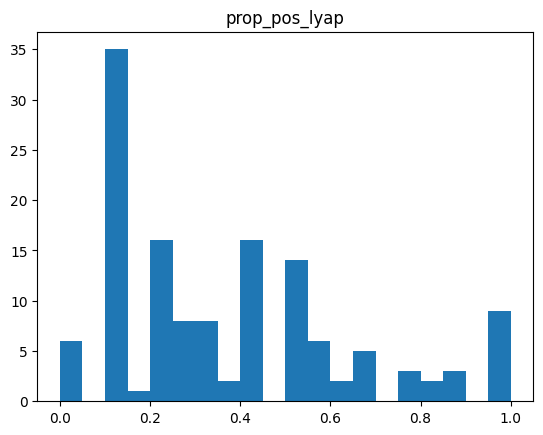

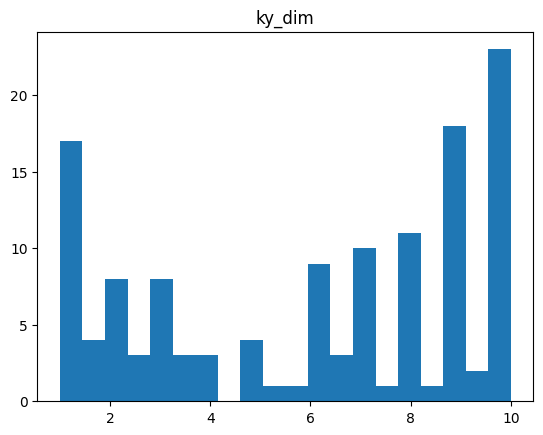

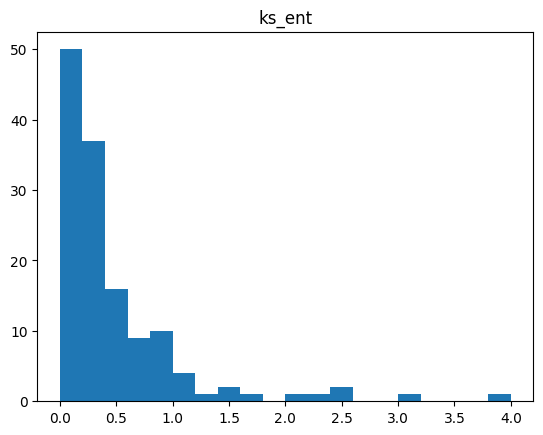

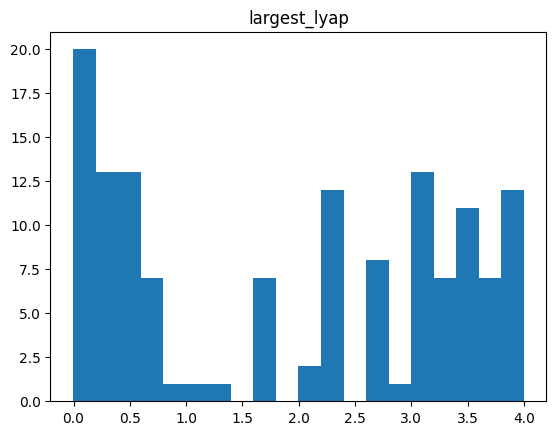

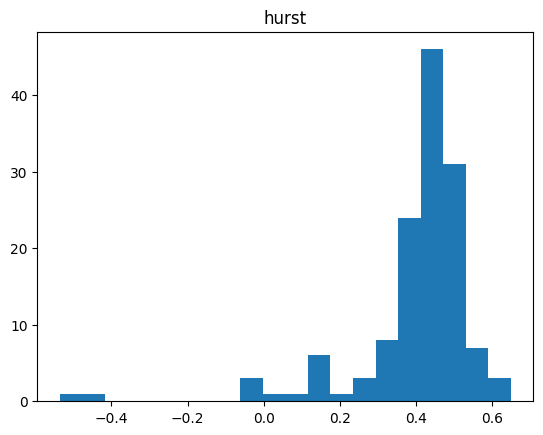

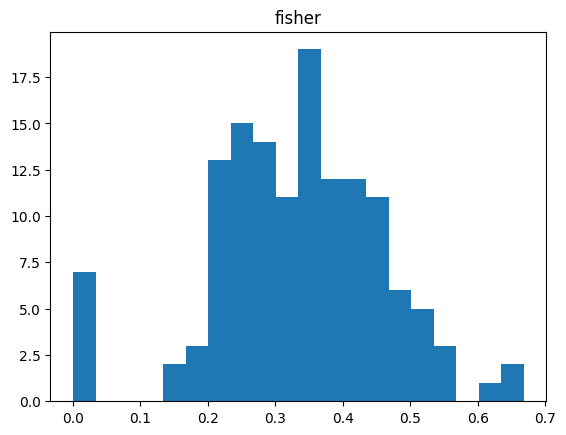

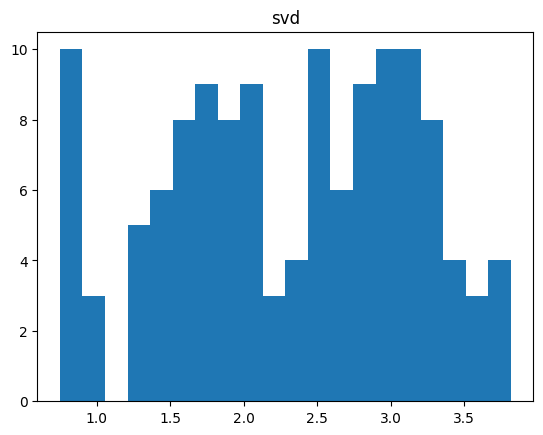

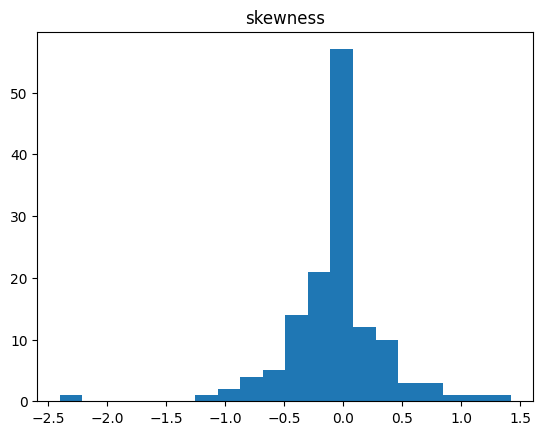

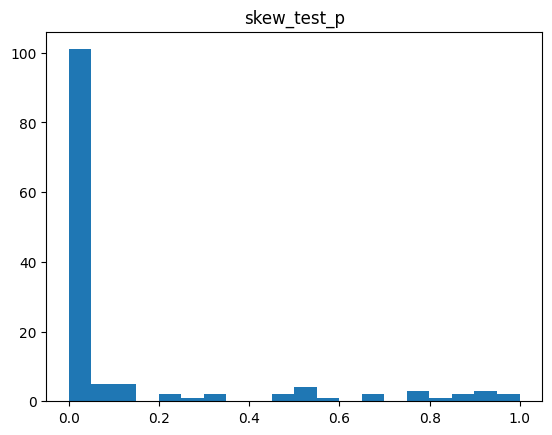

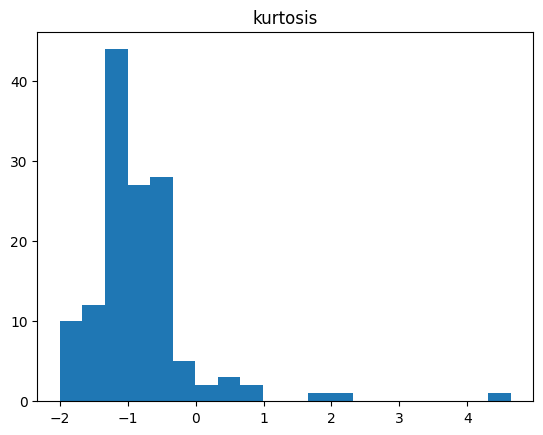

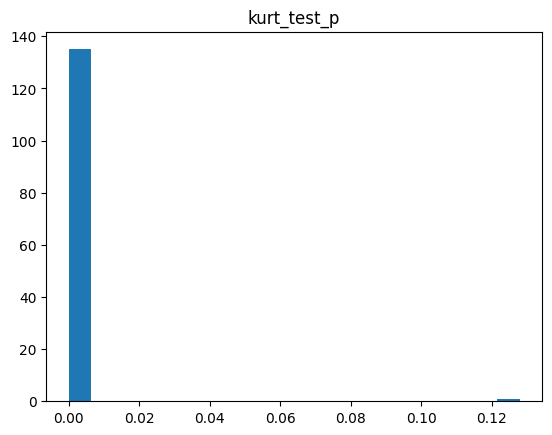

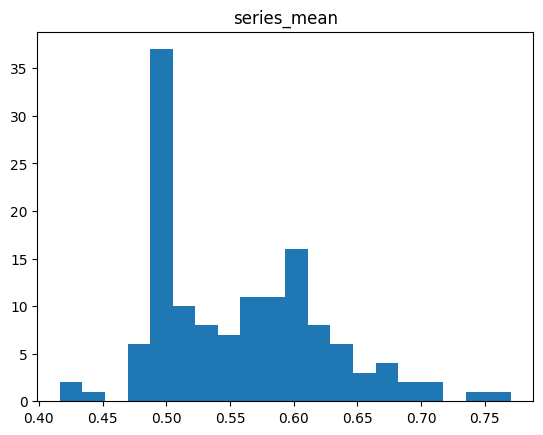

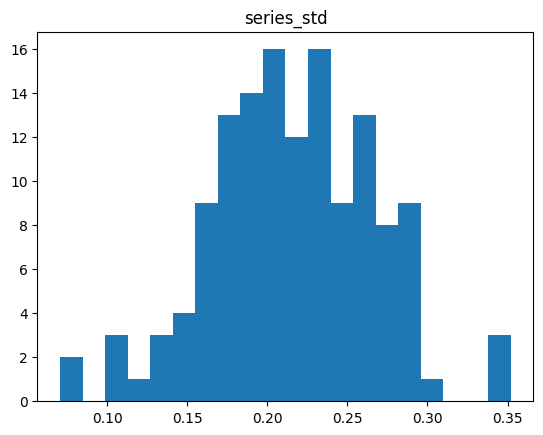

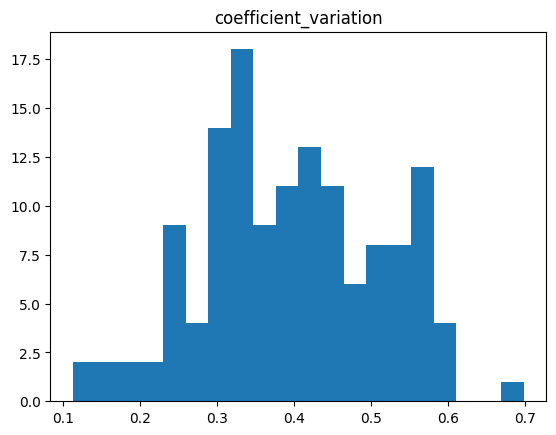

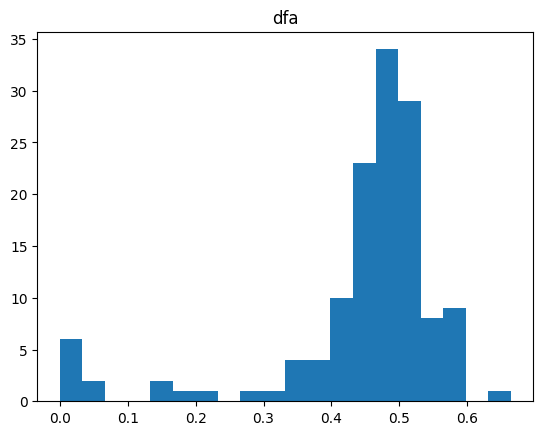

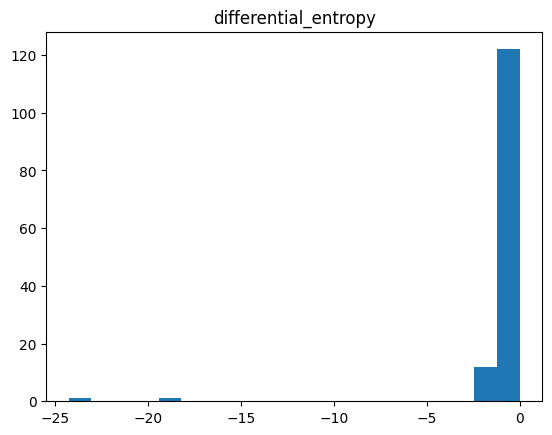

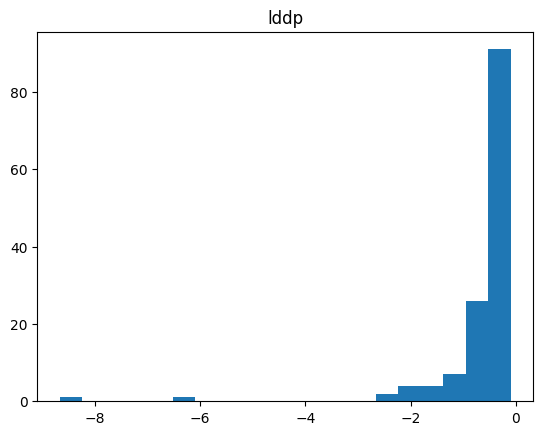

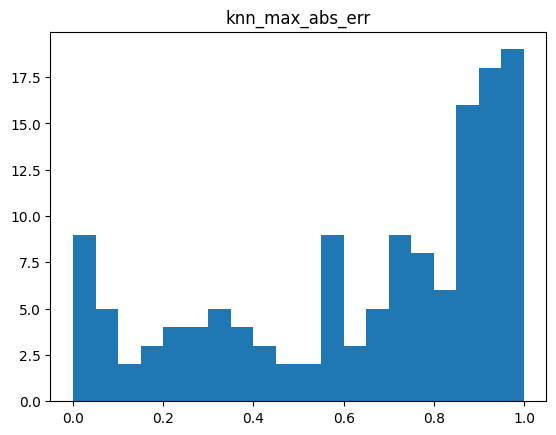

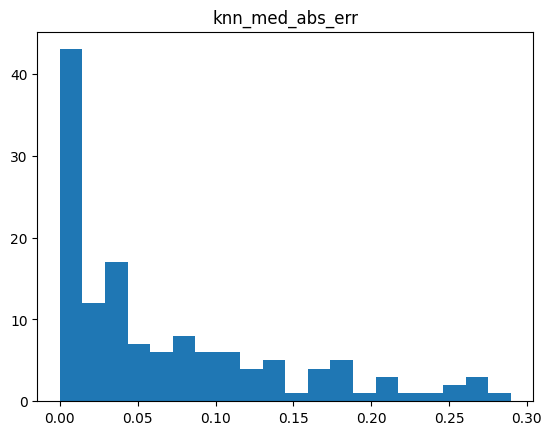

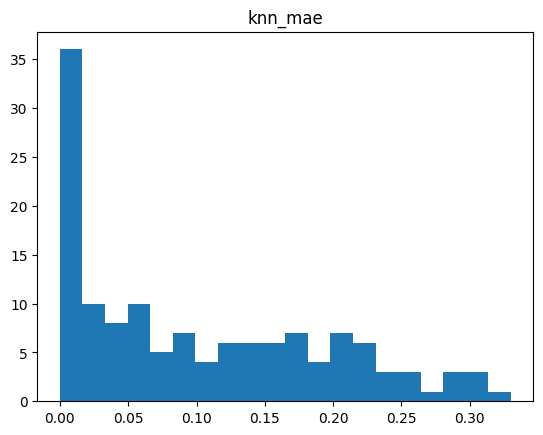

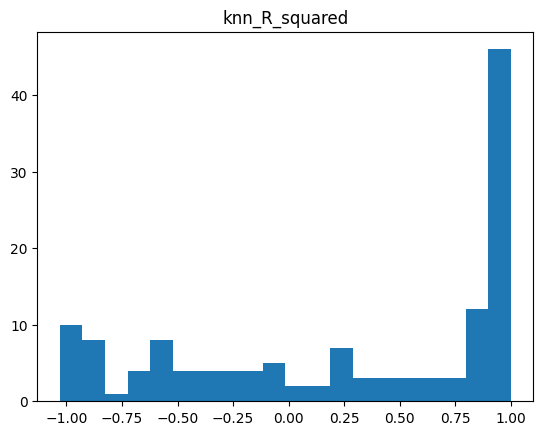

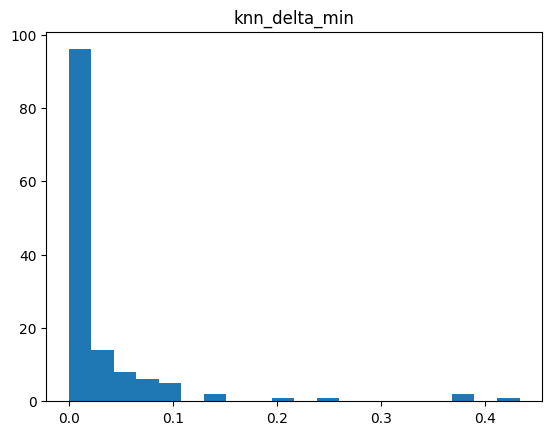

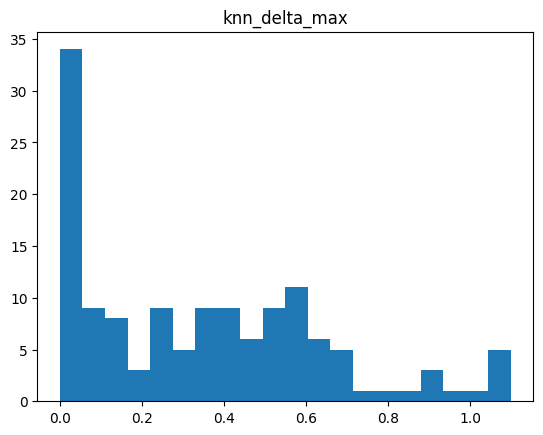

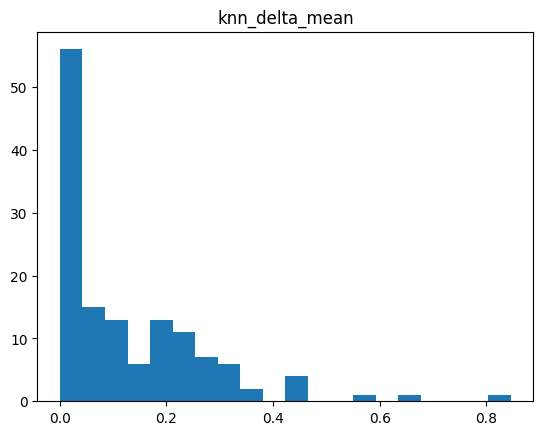

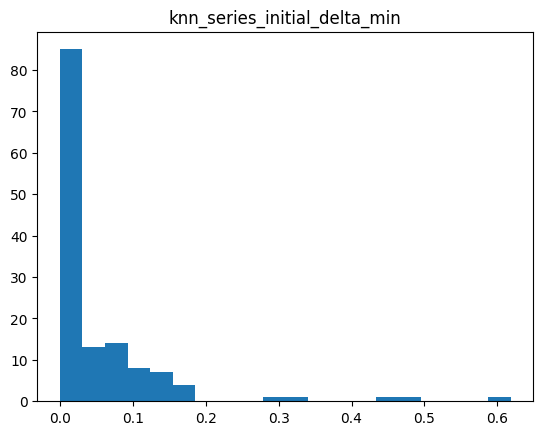

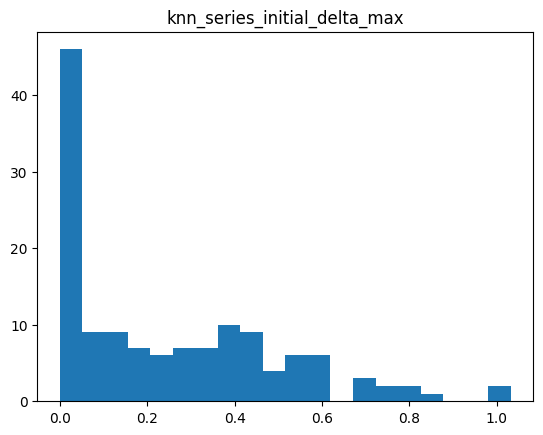

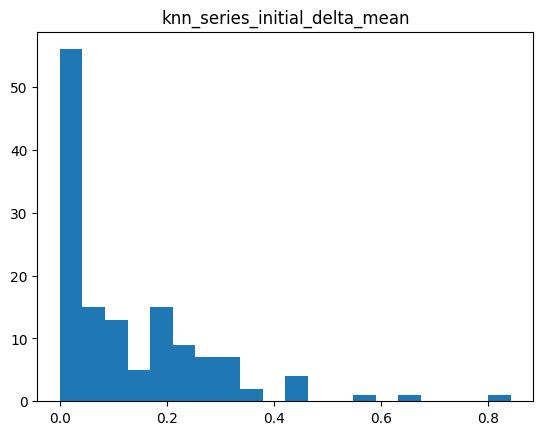

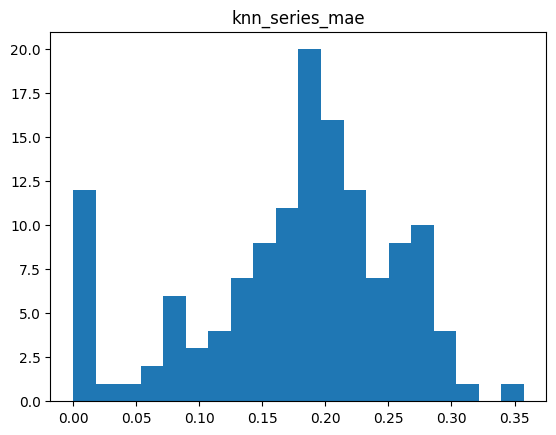

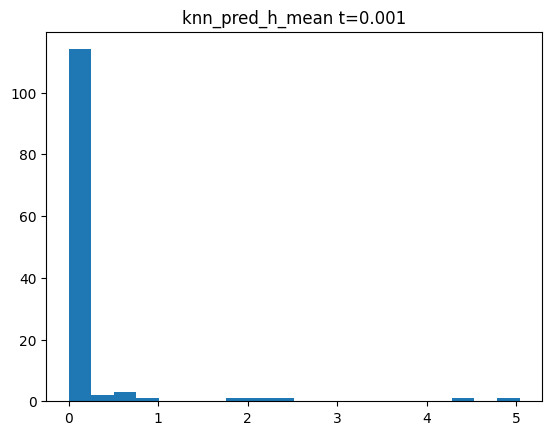

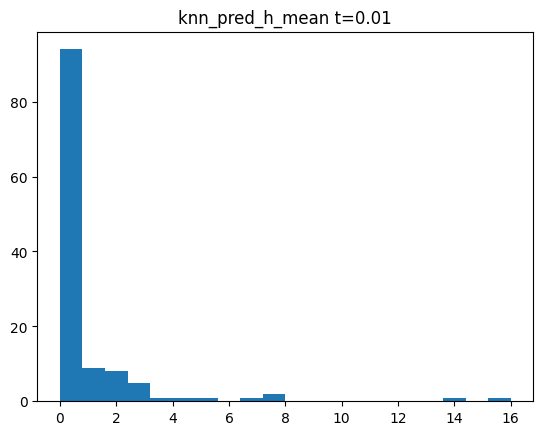

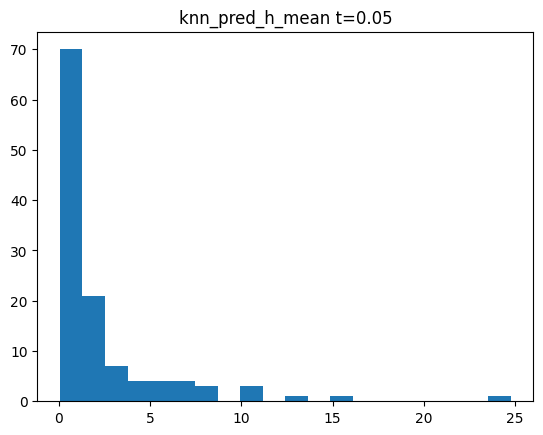

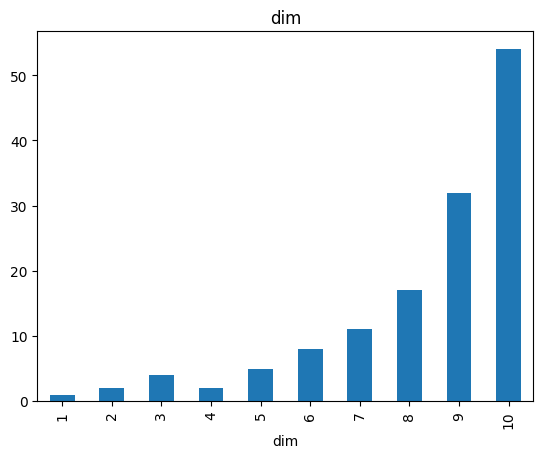

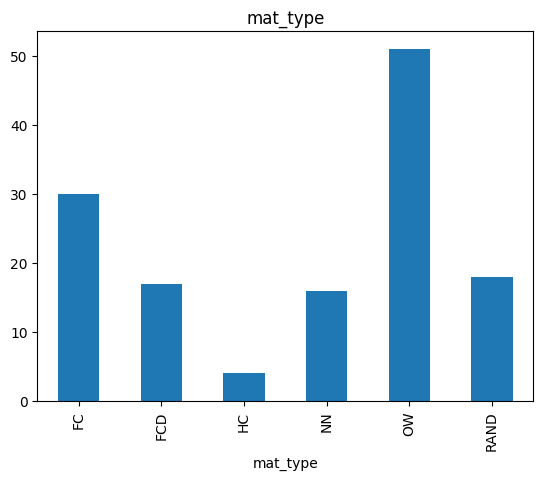

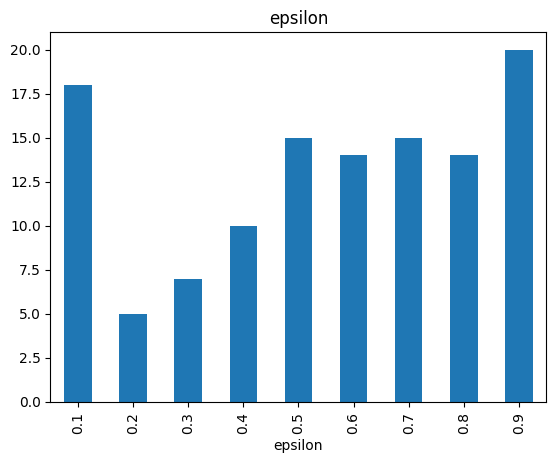

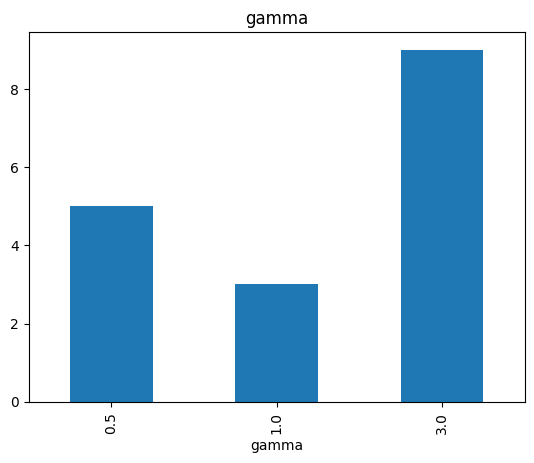

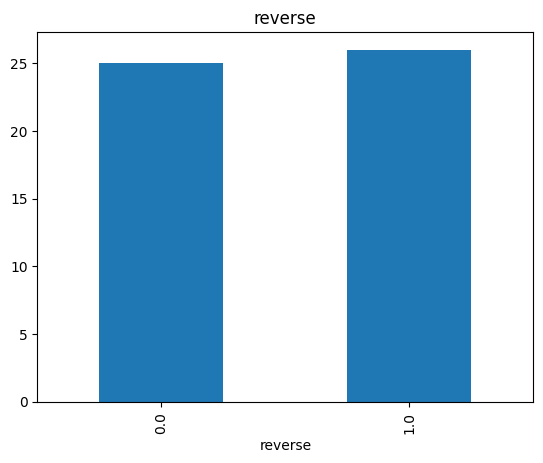

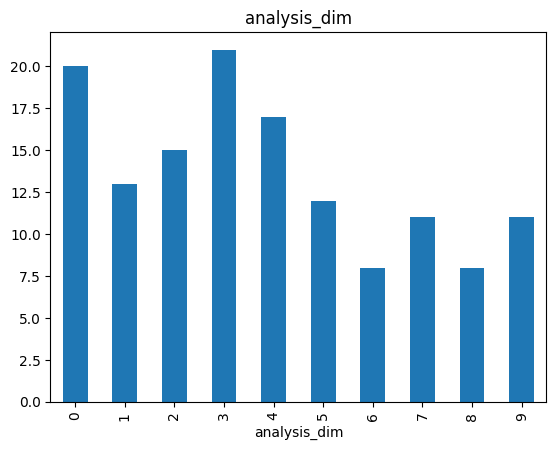

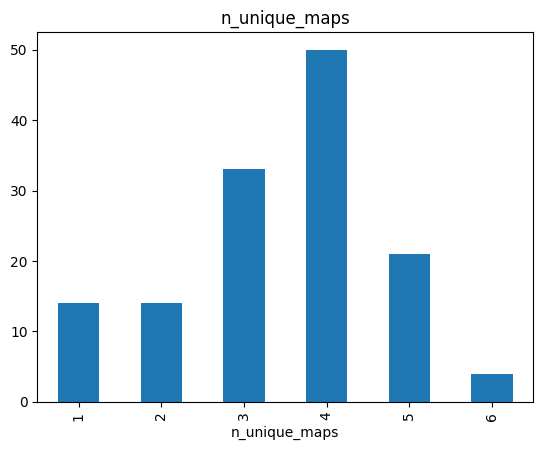

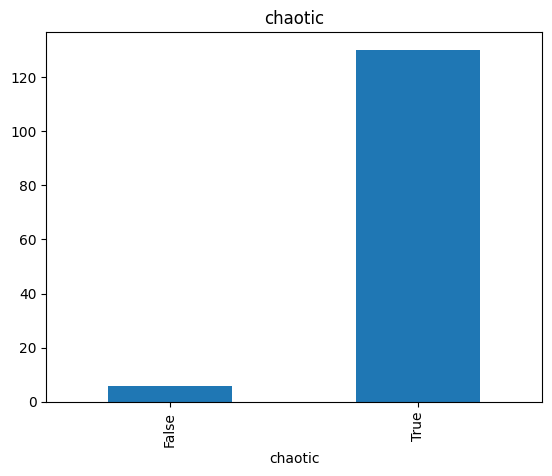

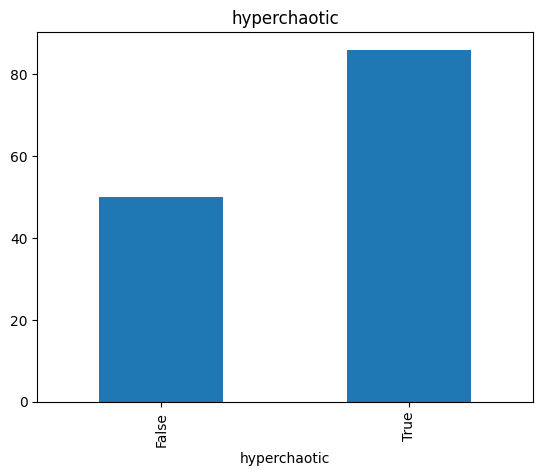

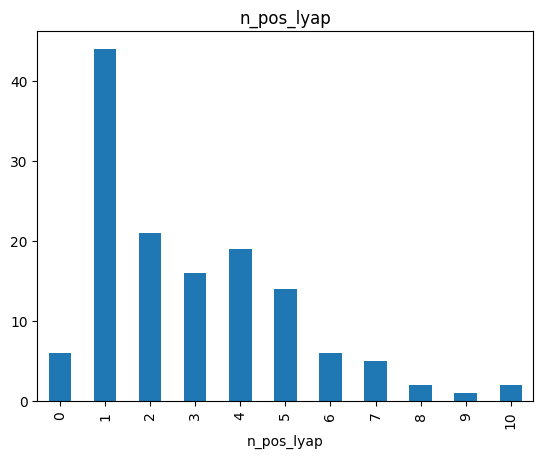

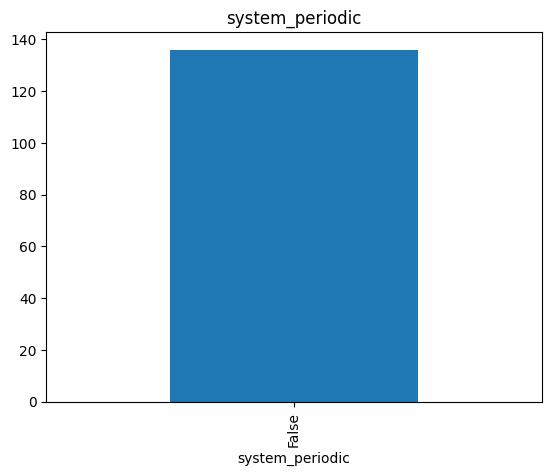

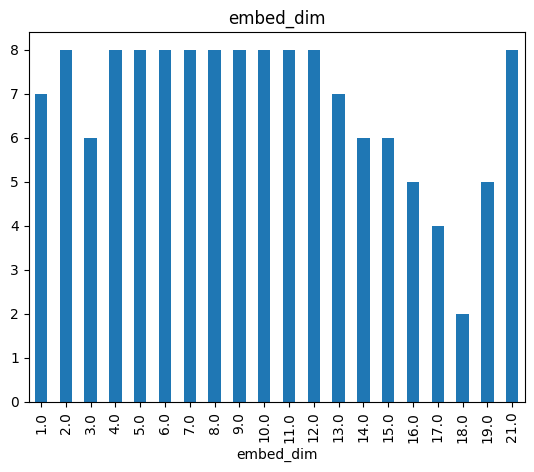

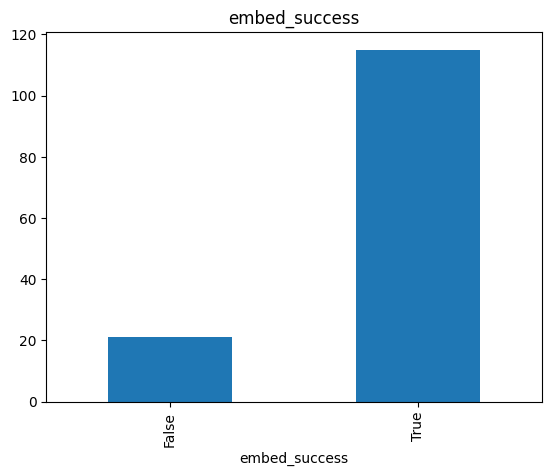

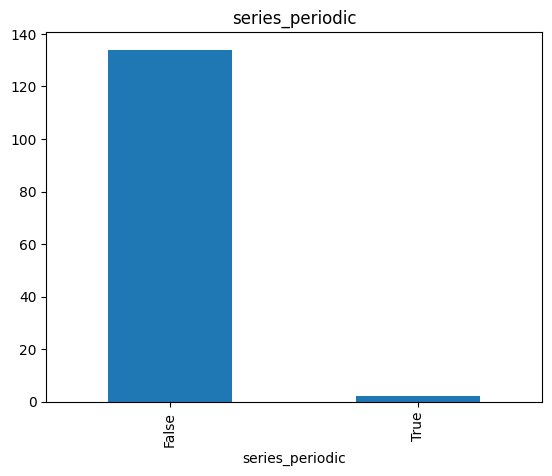

In [14]:
for m in cont_vars:
    arr = sample[m].replace([np.inf, -np.inf], np.nan).dropna()
    
    plt.figure()
    plt.hist(arr, bins=20)
    plt.title(m)
    plt.show()
    plt.close()

for m in discrete_vars:
    plt.figure()
    sample.groupby([m]).size().plot(kind='bar')
    plt.title(m)
    plt.show()
    plt.close()

## Modelling Params

In [15]:
n_layers = 4
layer_size = 200
lr = 0.001
batch_size = 32
lr_decay_factor = 0.1
epoch_vals = [100]

reps = 3

In [16]:
model_count = reps * len(sample)

print("{} models to train ({} systems; {} reps)".format(model_count, len(sample), reps))

408 models to train (136 systems; 3 reps)


In [17]:
update_at = np.unique(np.round(np.linspace(1, model_count, 100)))

In [18]:
models_complete = 0

result_list = []

for row_id, row in sample.iterrows():
    system_id = int(row['system_id'])
    sim_file = row['sim_file']
    modelling_len = int(row['modelling_len'])
    testing_len = int(row['testing_len'])
    n_tests = int(row['n_tests'])
    test_len = int(row['test_len'])
    embed_dim = int(row['embed_dim'])

    sim = np.load(sim_file)
    
    corrected_LDDP, corrected_LDDP_err = fn.calc_LDDP_corrected(sim)
    
    rqa_ts = TimeSeries(sim, embedding_dimension=embed_dim, time_delay=1)
    
    settings = Settings(rqa_ts)
    computation = RQAComputation.create(settings, verbose=False)
    result = computation.run()
    rqa_rr = result.recurrence_rate
    rqa_det = result.determinism
    
    assert len(sim) == modelling_len + testing_len
    modelling_series = sim[:modelling_len]
    testing_series = sim[-testing_len:]
    
    modelling_range = np.max(modelling_series) - np.min(modelling_series)
    sim_range = np.max(sim) - np.min(sim)
    
    assert len(modelling_series) == modelling_len
    assert len(testing_series) == testing_len
    test_dts = np.array(np.split(testing_series, n_tests))
    assert np.all(test_dts.shape == (n_tests, test_len))

    for rep_id in range(reps):
        
        result_dict = {
            "system_id": system_id,
            "embed_dim": embed_dim,
            "rep_id": rep_id,
            "modelling_range": modelling_range,
            "sim_range": sim_range,
            "corrected_LDDP": corrected_LDDP,
            "corrected_LDDP_err": corrected_LDDP_err,
            "RQA_rr": rqa_rr,
            "RQA_det": rqa_det
        }
        
        random_seed = int(10*system_id + rep_id)
        torch.manual_seed(random_seed)
        ##initialise model
        model = mlf.lstm(lstm_hs=layer_size, lstm_nl=n_layers)
        ## create dataloaders
        loader_dict = mlf.create_loaders(model_series=modelling_series, embed_dim=embed_dim, train_split=0.8,
                                         test_series=testing_series, batch_size=batch_size)
            
        trained_models, final_epoch, timings = mlf.train_model(model=model, train_loader=loader_dict["train_loader"],
                                        val_loader=loader_dict["val_loader"], epochs=epoch_vals, patience=100,
                                        loss_fn=torch.nn.L1Loss(), opt=torch.optim.Adam, start_lr=lr,
                                        lr_decay_factor=lr_decay_factor, if_save=False, save_folder=None, save_name=None,
                                        plot=False, verbose=False)

        result_dict["final_epoch"] = final_epoch

        for epoch_idx in range(len(trained_models)):
            final_dict = result_dict.copy()
            trained_model = trained_models[epoch_idx]
            final_dict["epoch"] = epoch_vals[epoch_idx]
            final_dict["model_time"] = timings[epoch_idx]
        
            final_dict["train_loss_mae"] = mlf.calc_loss(model=trained_model, dataloader=loader_dict["train_loader"], loss_fn=torch.nn.L1Loss())
            final_dict["val_loss_mae"] = mlf.calc_loss(model=trained_model, dataloader=loader_dict["val_loader"], loss_fn=torch.nn.L1Loss())
            final_dict.update(mlf.calc_point_metrics(model=trained_model, dataloader=loader_dict["test_loader"], prefix="test_loss"))
            
            pred_test_dts = mlf.pred_test_dts(test_dts=test_dts, model=trained_model, embed_dim=embed_dim)

            for t in [0.001, 0.01, 0.05]:
                pred_h = fn.calc_pred_h(test_dts=test_dts, pred_dts=pred_test_dts, embed_dim=embed_dim, thresh=t,
                                        percentiles=[1, 5, 10, 25, 50, 75, 90, 95, 99], if_plot=False)
                final_dict.update(pred_h)
            
            result_list.append(final_dict)
            
        models_complete += 1
        if models_complete in update_at:
            print("Completed training model {} of {} ({}%)".format(models_complete, model_count, np.round(100*(models_complete/model_count), 2)))

C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Completed training model 1 of 408 (0.25%)


C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Completed training model 5 of 408 (1.23%)


C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


...

Completed training model 367 of 408 (89.95%)
Completed training model 371 of 408 (90.93%)


C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value enc

Completed training model 375 of 408 (91.91%)
Completed training model 379 of 408 (92.89%)
Completed training model 383 of 408 (93.87%)


C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\B00955739\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value enc

Completed training model 387 of 408 (94.85%)
Completed training model 392 of 408 (96.08%)
Completed training model 396 of 408 (97.06%)
Completed training model 400 of 408 (98.04%)
Completed training model 404 of 408 (99.02%)
Completed training model 408 of 408 (100.0%)


In [19]:
res_df = pd.DataFrame(result_list)
res_df.head()

,system_id,embed_dim,rep_id,modelling_range,sim_range,corrected_LDDP,corrected_LDDP_err,RQA_rr,RQA_det,final_epoch,...,pred_h_p5 t=0.05,pred_h_p10 t=0.05,pred_h_p25 t=0.05,pred_h_p50 t=0.05,pred_h_p75 t=0.05,pred_h_p90 t=0.05,pred_h_p95 t=0.05,pred_h_p99 t=0.05,pred_h_sd t=0.05,pred_h_perfect_pred_count t=0.05
0,18583,1,0,0.645101,0.645101,-2.089063,2.220446e-16,1.0,1.0,100,...,6.0,6.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,33
1,18583,1,1,0.645101,0.645101,-2.089063,2.220446e-16,1.0,1.0,100,...,6.0,6.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,33
2,18583,1,2,0.645101,0.645101,-2.089063,2.220446e-16,1.0,1.0,100,...,6.0,6.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,29
3,237766,1,0,0.435820,0.435820,-2.227944,-2.220446e-16,1.0,1.0,100,...,1.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0,0.975500,0
4,237766,1,1,0.435820,0.435820,-2.227944,-2.220446e-16,1.0,1.0,100,...,1.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,0.854166,0


In [20]:
print("Saving CSV: {}".format(folder + out_name + ".csv"))

res_df.to_csv(folder + out_name + ".csv")

Saving CSV: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/modelling_run_v1.csv


In [21]:
print(len(res_df))

408
